In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [5]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')

DATA_PATH = None
for root, dirs, files in os.walk('/kaggle/input'):
    if 'assessments.csv' in files:
        DATA_PATH = root
        break

print("Dataset directory:", DATA_PATH)

studentInfo = pd.read_csv(os.path.join(DATA_PATH, 'studentInfo.csv'))
studentRegistration = pd.read_csv(os.path.join(DATA_PATH, 'studentRegistration.csv'))
studentVle = pd.read_csv(os.path.join(DATA_PATH, 'studentVle.csv'))
vle = pd.read_csv(os.path.join(DATA_PATH, 'vle.csv'))
assessments = pd.read_csv(os.path.join(DATA_PATH, 'assessments.csv'))
studentAssessment = pd.read_csv(os.path.join(DATA_PATH, 'studentAssessment.csv'))

print("Data loaded successfully.")

Dataset directory: /kaggle/input/datasets/anlgrbz/student-demographics-online-education-dataoulad
Data loaded successfully.


In [6]:
# Impute missing assessment scores with 0
student_assess = assessments.merge(studentAssessment, on='id_assessment', how='inner')
student_assess['score'] = student_assess['score'].fillna(0)

# Impute missing imd_band using region mode
for reg in studentInfo['region'].unique():
    mode_val = studentInfo[studentInfo['region'] == reg]['imd_band'].mode()
    if not mode_val.empty:
        studentInfo.loc[(studentInfo['imd_band'].isnull()) & (studentInfo['region'] == reg), 'imd_band'] = mode_val[0]

# Filter valid student registrations
valid_reg = studentRegistration[~(studentRegistration['date_unregistration'] < 0)]

# Pre-filter forum activities for SNA metrics
forum_sites = vle[vle['activity_type'] == 'forumng']['id_site'].unique()
forum_vle = studentVle[studentVle['id_site'].isin(forum_sites)]

print("Data cleaning completed.")
print("Valid student records:", len(valid_reg))

Data cleaning completed.
Valid student records: 29915


In [7]:
def create_enhanced_snapshot_dataset(snapshot_days):
    # 1. VLE Click Features + Recency
    v_sub = studentVle[studentVle['date'] <= snapshot_days]
    vle_features = v_sub.groupby(['code_module', 'code_presentation', 'id_student']).agg(
        total_clicks=('sum_click', 'sum'),
        click_frequency=('sum_click', 'count'),
        active_days=('date', 'nunique'),
        max_active_day=('date', 'max')
    ).reset_index()
    
    vle_features['days_since_last_click'] = snapshot_days - vle_features['max_active_day']
    vle_features = vle_features.drop(columns=['max_active_day'])

    # 2. Assessment Features + Range Statistics
    a_sub = student_assess[student_assess['date'] <= snapshot_days]
    assess_features = a_sub.groupby(['code_module', 'code_presentation', 'id_student']).agg(
        mean_score=('score', 'mean'),
        min_score=('score', 'min'),
        max_score=('score', 'max'),
        total_weight=('weight', 'sum'),
        assessments_count=('id_assessment', 'count')
    ).reset_index()

    # 3. SNA Features
    f_sub = forum_vle[forum_vle['date'] <= snapshot_days]
    total_forums = vle[vle['activity_type'] == 'forumng'].groupby(['code_module', 'code_presentation'])['id_site'].nunique().to_dict()
    
    sna_features = f_sub.groupby(['code_module', 'code_presentation', 'id_student']).agg(
        unique_forums=('id_site', 'nunique'),
        forum_clicks=('sum_click', 'sum')
    ).reset_index()

    def calc_deg(row):
        tot = total_forums.get((row['code_module'], row['code_presentation']), 1)
        return row['unique_forums'] / tot if tot > 0 else 0.0

    sna_features['degree_centrality'] = sna_features.apply(calc_deg, axis=1)
    sna_features['closeness_centrality'] = sna_features['forum_clicks'] / (sna_features['forum_clicks'].max() + 1e-5)
    sna_features = sna_features.drop(columns=['unique_forums', 'forum_clicks'])

    # Merge with base student info
    df = studentInfo.merge(
        valid_reg[['code_module', 'code_presentation', 'id_student']],
        on=['code_module', 'code_presentation', 'id_student'],
        how='inner'
    )

    df = df.merge(vle_features, on=['code_module', 'code_presentation', 'id_student'], how='left')
    df = df.merge(assess_features, on=['code_module', 'code_presentation', 'id_student'], how='left')
    df = df.merge(sna_features, on=['code_module', 'code_presentation', 'id_student'], how='left')

    fill_cols = [
        'total_clicks', 'click_frequency', 'active_days', 
        'mean_score', 'min_score', 'max_score', 'total_weight', 'assessments_count', 
        'degree_centrality', 'closeness_centrality'
    ]
    
    df['days_since_last_click'] = df['days_since_last_click'].fillna(snapshot_days)
    df[fill_cols] = df[fill_cols].fillna(0)

    # Simplify Target (Distinction -> Pass)
    df['final_result'] = df['final_result'].replace('Distinction', 'Pass')

    print(f"Enhanced snapshot dataset built (day <= {snapshot_days}). Shape: {df.shape}")
    return df

df_snapshot_1 = create_enhanced_snapshot_dataset(snapshot_days=100)
df_snapshot_2 = create_enhanced_snapshot_dataset(snapshot_days=200)

Enhanced snapshot dataset built (day <= 100). Shape: (29915, 23)
Enhanced snapshot dataset built (day <= 200). Shape: (29915, 23)


In [8]:
def prepare_and_evaluate(df, snapshot_label):
    df_ml = df.copy()
    cat_cols = ['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability', 'code_module', 'code_presentation']
    
    le = LabelEncoder()
    for col in cat_cols:
        df_ml[col] = le.fit_transform(df_ml[col].astype(str))

    target_le = LabelEncoder()
    y = target_le.fit_transform(df_ml['final_result'])
    X = df_ml.drop(columns=['id_student', 'final_result'])

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

    # Balance classes in training data using SMOTE
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    models = {
        'Decision Tree': DecisionTreeClassifier(max_depth=12, random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=150, max_depth=15, random_state=42, n_jobs=-1),
        'XGBoost': XGBClassifier(n_estimators=150, max_depth=6, learning_rate=0.08, random_state=42)
    }

    results = []
    for name, model in models.items():
        model.fit(X_train_res, y_train_res)
        preds = model.predict(X_test)
        
        results.append({
            'Snapshot': snapshot_label,
            'Model': name,
            'Accuracy': round(accuracy_score(y_test, preds), 4),
            'Precision': round(precision_score(y_test, preds, average='macro'), 4),
            'Recall': round(recall_score(y_test, preds, average='macro'), 4),
            'F1-Score': round(f1_score(y_test, preds, average='macro'), 4)
        })

    return pd.DataFrame(results)

summary_s1 = prepare_and_evaluate(df_snapshot_1, "Snapshot 1 (Day <= 100)")
summary_s2 = prepare_and_evaluate(df_snapshot_2, "Snapshot 2 (Day <= 200)")

print("\nEnhanced Comparative Model Performance Summary:")
print(pd.concat([summary_s1, summary_s2], ignore_index=True).to_string(index=False))


Enhanced Comparative Model Performance Summary:
               Snapshot         Model  Accuracy  Precision  Recall  F1-Score
Snapshot 1 (Day <= 100) Decision Tree    0.6724     0.6168  0.6106    0.6133
Snapshot 1 (Day <= 100) Random Forest    0.7088     0.6541  0.6426    0.6468
Snapshot 1 (Day <= 100)       XGBoost    0.7160     0.6628  0.6511    0.6549
Snapshot 2 (Day <= 200) Decision Tree    0.7383     0.6785  0.6803    0.6793
Snapshot 2 (Day <= 200) Random Forest    0.7754     0.7168  0.7163    0.7148
Snapshot 2 (Day <= 200)       XGBoost    0.7767     0.7191  0.7179    0.7167


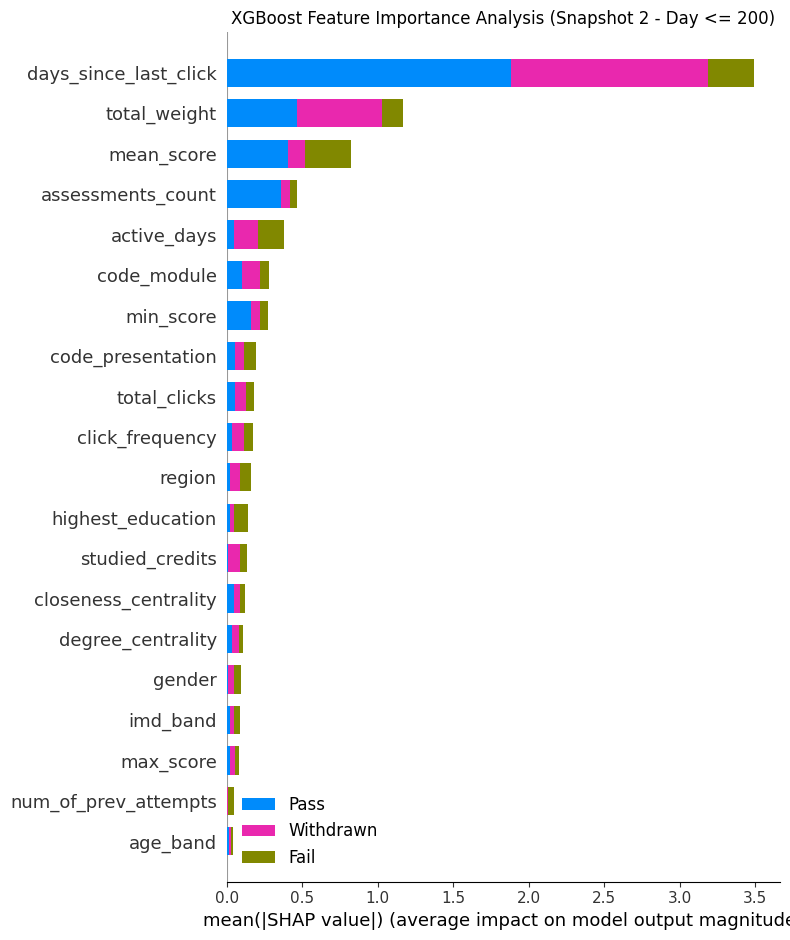

In [9]:
import shap

# Re-prepare Snapshot 2 features
df_ml = df_snapshot_2.copy()
cat_cols = ['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability', 'code_module', 'code_presentation']

le = LabelEncoder()
for col in cat_cols:
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))

target_le = LabelEncoder()
y = target_le.fit_transform(df_ml['final_result'])
X = df_ml.drop(columns=['id_student', 'final_result'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Fit best model
xgb_model = XGBClassifier(n_estimators=150, max_depth=6, learning_rate=0.08, random_state=42)
xgb_model.fit(X_train, y_train)

# SHAP values calculation
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, class_names=target_le.classes_, plot_type="bar", show=False)
plt.title("XGBoost Feature Importance Analysis (Snapshot 2 - Day <= 200)")
plt.tight_layout()
plt.show()

EWS Intervention Zone Distribution:
intervention_zone
Safe Zone         2177
Critical Risk     2144
Academic Risk      847
Isolation Risk     815
Name: count, dtype: int64

Sample EWS Student Profiling Output:
 id_student code_module code_presentation  total_clicks  degree_centrality  mean_score  academic_risk_score predicted_status intervention_zone
     519859         BBB             2014B        1036.0           0.588235   90.636364             0.003561             Pass         Safe Zone
     607938         FFF             2013J        2611.0           0.571429   63.800000             0.212426             Pass         Safe Zone
     698586         BBB             2014J          16.0           0.000000    0.000000             0.999603        Withdrawn     Critical Risk
     590762         DDD             2013J         498.0           0.125000   85.000000             0.042782             Pass     Critical Risk
     626428         BBB             2014B         182.0           0.294118 

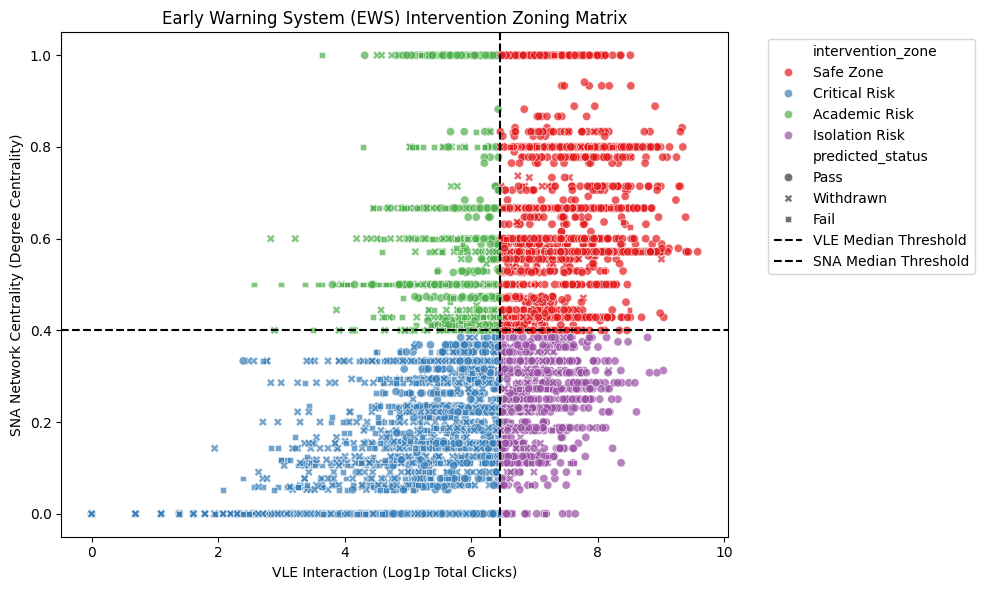

In [10]:
# Predictions and probability scores
preds = xgb_model.predict(X_test)
probs = xgb_model.predict_proba(X_test)

df_test = df_snapshot_2.iloc[X_test.index].copy()
df_test['predicted_status'] = target_le.inverse_transform(preds)

# Calculate academic risk probability
fail_idx = list(target_le.classes_).index('Fail')
withdrawn_idx = list(target_le.classes_).index('Withdrawn') if 'Withdrawn' in target_le.classes_ else None

if withdrawn_idx is not None:
    df_test['academic_risk_score'] = probs[:, fail_idx] + probs[:, withdrawn_idx]
else:
    df_test['academic_risk_score'] = probs[:, fail_idx]

# Quadrant boundaries based on dataset medians
vle_med = df_test['total_clicks'].median()
sna_med = df_test['degree_centrality'].median()

def assign_zone(row):
    vle_high = row['total_clicks'] >= vle_med
    sna_high = row['degree_centrality'] >= sna_med
    if vle_high and sna_high:
        return 'Safe Zone'
    elif not vle_high and sna_high:
        return 'Academic Risk'
    elif vle_high and not sna_high:
        return 'Isolation Risk'
    else:
        return 'Critical Risk'

df_test['intervention_zone'] = df_test.apply(assign_zone, axis=1)

print("EWS Intervention Zone Distribution:")
print(df_test['intervention_zone'].value_counts())

print("\nSample EWS Student Profiling Output:")
cols_to_show = ['id_student', 'code_module', 'code_presentation', 'total_clicks', 'degree_centrality', 'mean_score', 'academic_risk_score', 'predicted_status', 'intervention_zone']
print(df_test[cols_to_show].head(10).to_string(index=False))

# Scatter plot for EWS Matrix
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_test,
    x=np.log1p(df_test['total_clicks']),
    y=df_test['degree_centrality'],
    hue='intervention_zone',
    style='predicted_status',
    palette='Set1',
    alpha=0.7
)

plt.axvline(x=np.log1p(vle_med), color='black', linestyle='--', label='VLE Median Threshold')
plt.axhline(y=sna_med, color='black', linestyle='--', label='SNA Median Threshold')
plt.title("Early Warning System (EWS) Intervention Zoning Matrix")
plt.xlabel("VLE Interaction (Log1p Total Clicks)")
plt.ylabel("SNA Network Centrality (Degree Centrality)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

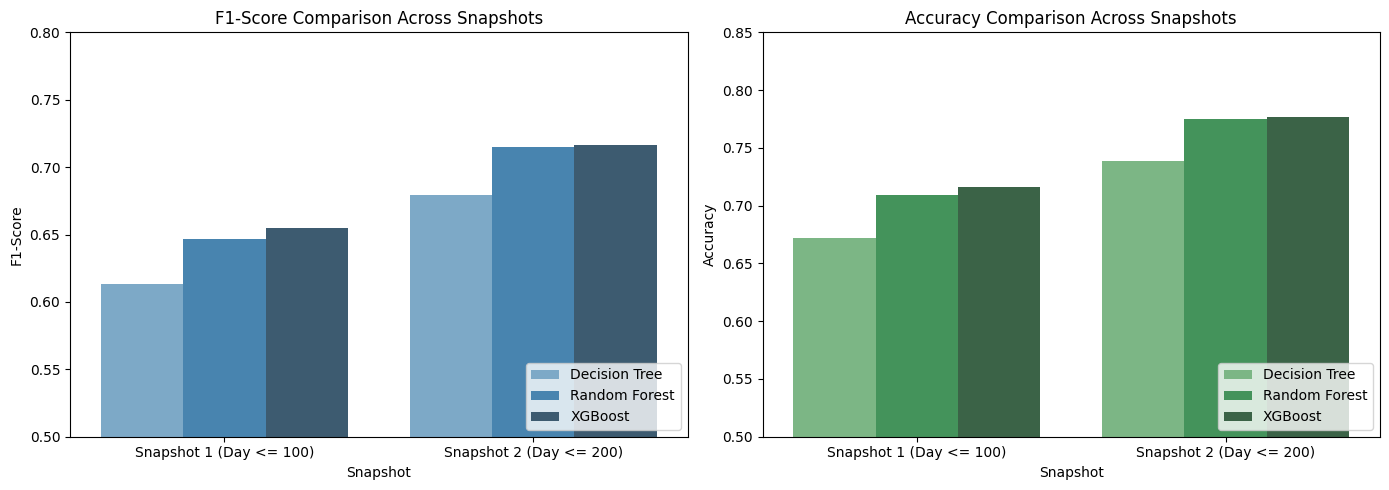

In [11]:
# Combine evaluation summaries
summary_combined = pd.concat([summary_s1, summary_s2], ignore_index=True)

plt.figure(figsize=(14, 5))

# Plot F1-Score
plt.subplot(1, 2, 1)
sns.barplot(data=summary_combined, x="Snapshot", y="F1-Score", hue="Model", palette="Blues_d")
plt.title("F1-Score Comparison Across Snapshots")
plt.ylim(0.5, 0.8)
plt.legend(loc="lower right")

# Plot Accuracy
plt.subplot(1, 2, 2)
sns.barplot(data=summary_combined, x="Snapshot", y="Accuracy", hue="Model", palette="Greens_d")
plt.title("Accuracy Comparison Across Snapshots")
plt.ylim(0.5, 0.85)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

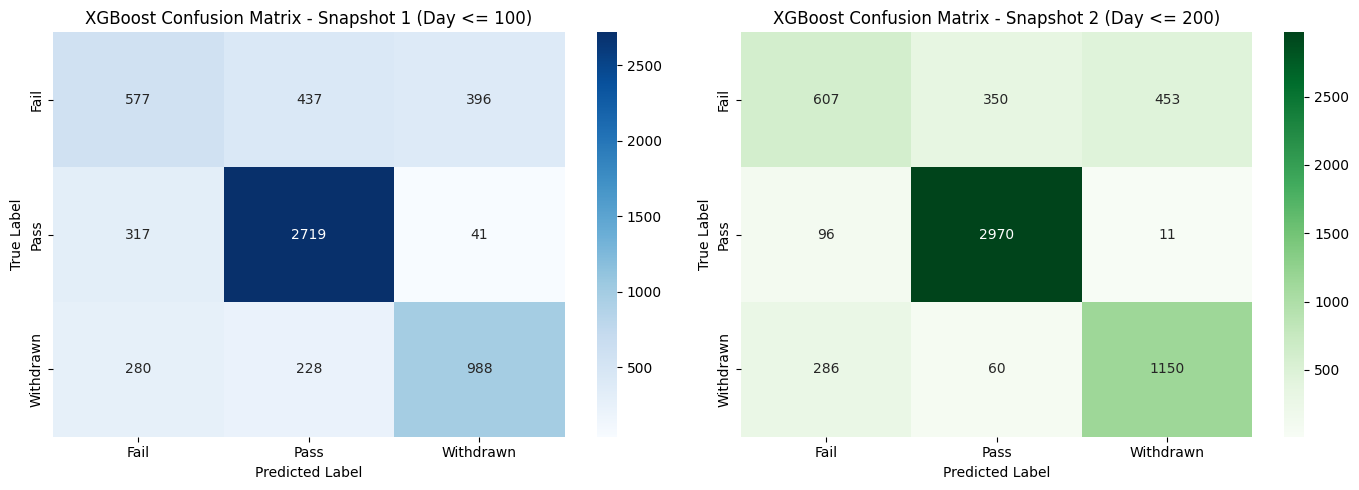

In [12]:
from sklearn.metrics import confusion_matrix

# Train XGBoost on Snapshot 1 with SMOTE for comparison
df_ml_s1 = df_snapshot_1.copy()
cat_cols = ['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability', 'code_module', 'code_presentation']

le_s1 = LabelEncoder()
for col in cat_cols:
    df_ml_s1[col] = le_s1.fit_transform(df_ml_s1[col].astype(str))

y_s1 = target_le.transform(df_ml_s1['final_result'])
X_s1 = df_ml_s1.drop(columns=['id_student', 'final_result'])

X_train_s1, X_test_s1, y_train_s1, y_test_s1 = train_test_split(X_s1, y_s1, test_size=0.20, random_state=42, stratify=y_s1)

smote = SMOTE(random_state=42)
X_train_s1_res, y_train_s1_res = smote.fit_resample(X_train_s1, y_train_s1)

xgb_s1 = XGBClassifier(n_estimators=150, max_depth=6, learning_rate=0.08, random_state=42)
xgb_s1.fit(X_train_s1_res, y_train_s1_res)

preds_s1 = xgb_s1.predict(X_test_s1)
preds_s2 = xgb_model.predict(X_test)

cm_s1 = confusion_matrix(y_test_s1, preds_s1)
cm_s2 = confusion_matrix(y_test, preds_s2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_s1, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=target_le.classes_, yticklabels=target_le.classes_)
axes[0].set_title("XGBoost Confusion Matrix - Snapshot 1 (Day <= 100)")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

sns.heatmap(cm_s2, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=target_le.classes_, yticklabels=target_le.classes_)
axes[1].set_title("XGBoost Confusion Matrix - Snapshot 2 (Day <= 200)")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()

In [13]:
import joblib

# Export EWS profiling output to CSV
df_test.to_csv("ews_student_profiling_results.csv", index=False)
print("EWS profiling results saved to 'ews_student_profiling_results.csv'")

# Export trained XGBoost model to PKL
joblib.dump(xgb_model, "xgb_ews_model_snapshot2.pkl")
print("Trained XGBoost model saved to 'xgb_ews_model_snapshot2.pkl'")

EWS profiling results saved to 'ews_student_profiling_results.csv'
Trained XGBoost model saved to 'xgb_ews_model_snapshot2.pkl'


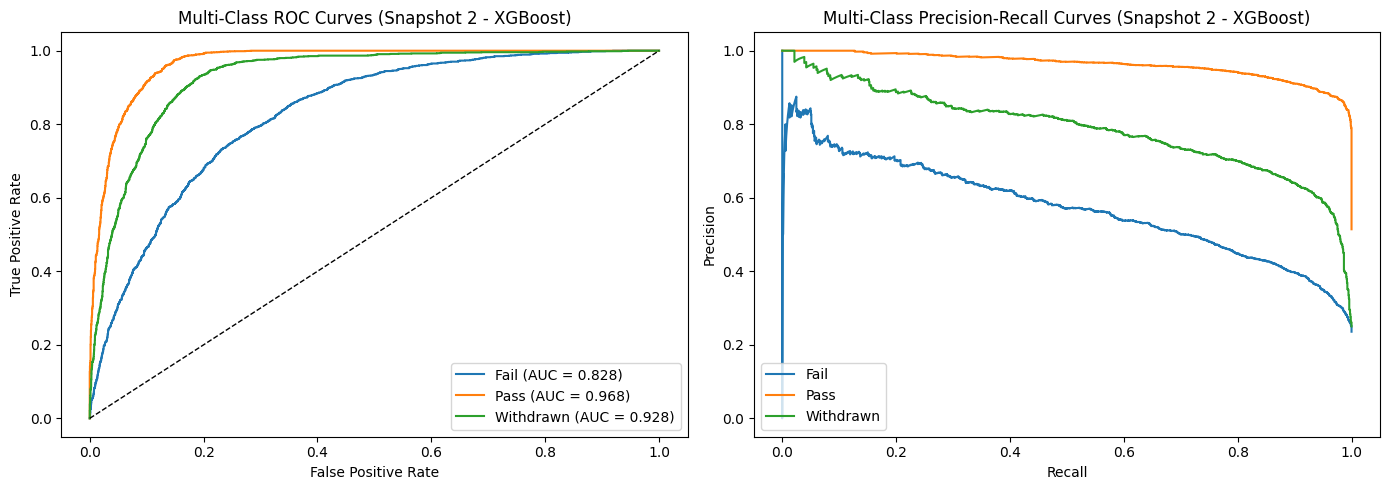

In [14]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize

# Binarize target labels for One-Vs-Rest (OvR) evaluation
y_test_bin = label_binarize(y_test, classes=range(len(target_le.classes_)))
n_classes = y_test_bin.shape[1]
probs_s2 = xgb_model.predict_proba(X_test)

plt.figure(figsize=(14, 5))

# Plot OvR ROC Curves
plt.subplot(1, 2, 1)
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs_s2[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{target_le.classes_[i]} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curves (Snapshot 2 - XGBoost)')
plt.legend(loc="lower right")

# Plot OvR Precision-Recall Curves
plt.subplot(1, 2, 2)
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], probs_s2[:, i])
    plt.plot(recall, precision, label=f"{target_le.classes_[i]}")

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Multi-Class Precision-Recall Curves (Snapshot 2 - XGBoost)')
plt.legend(loc="lower left")

plt.tight_layout()
plt.show()

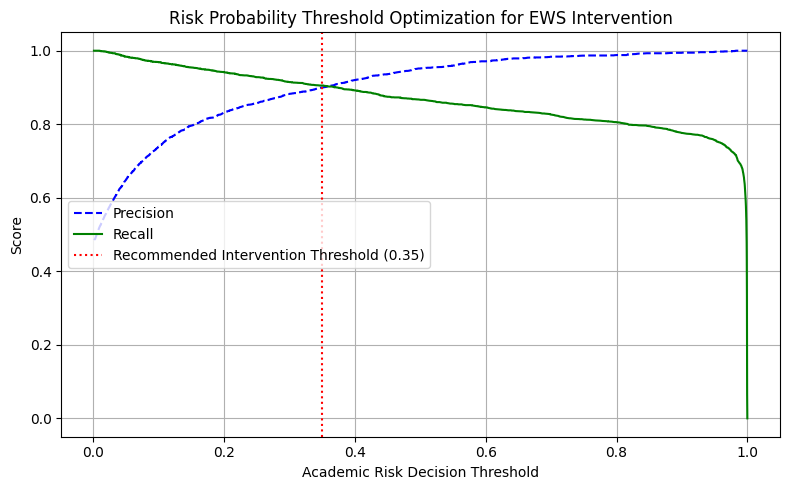

In [15]:
# Define binary risk label: 1 if (Fail or Withdrawn), 0 if Pass
pass_idx = list(target_le.classes_).index('Pass')
y_test_risk = (y_test != pass_idx).astype(int)
probs_risk = df_test['academic_risk_score'].values

precisions, recalls, thresholds = precision_recall_curve(y_test_risk, probs_risk)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
plt.xlabel("Academic Risk Decision Threshold")
plt.ylabel("Score")
plt.title("Risk Probability Threshold Optimization for EWS Intervention")
plt.axvline(x=0.35, color="red", linestyle=":", label="Recommended Intervention Threshold (0.35)")
plt.legend(loc="center left")
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
def get_student_ews_profile(student_id, df_ews=df_test):
    student_data = df_ews[df_ews['id_student'] == student_id]
    if student_data.empty:
        print(f"Student ID {student_id} not found in the evaluation set.")
        return

    row = student_data.iloc[0]
    print("=" * 65)
    print(f"EWS INDIVIDUAL PROFILE: STUDENT ID {row['id_student']}")
    print("=" * 65)
    print(f"Course Module       : {row['code_module']} ({row['code_presentation']})")
    print(f"Predicted Status    : {row['predicted_status'].upper()}")
    print(f"Academic Risk Score : {row['academic_risk_score']:.4f}")
    print(f"Intervention Zone   : {row['intervention_zone']}")
    print("-" * 65)
    print("BEHAVIORAL & ACADEMIC METRICS:")
    print(f"- Total VLE Clicks       : {row['total_clicks']}")
    print(f"- Active Learning Days   : {row['active_days']}")
    print(f"- Days Since Last Click  : {row['days_since_last_click']}")
    print(f"- Assessment Mean Score  : {row['mean_score']:.2f}")
    print(f"- Degree Centrality (SNA): {row['degree_centrality']:.4f}")
    print("-" * 65)
    print("RECOMMENDED INTERVENTION STRATEGY:")
    
    zone = row['intervention_zone']
    if zone == 'Safe Zone':
        print("-> Maintain current learning trajectory and active peer collaboration.")
    elif zone == 'Academic Risk':
        print("-> Student is socially integrated but struggling academically.")
        print("   Action: Academic tutoring, targeted module review, and assignment assistance.")
    elif zone == 'Isolation Risk':
        print("-> Student is academically active but socially isolated.")
        print("   Action: Encourage peer study group formation and forum interaction.")
    else: # Critical Risk
        print("-> HIGH DROPOUT RISK: Low academic engagement and social isolation.")
        print("   Action: Immediate direct intervention by academic advisor & pastoral support.")
    print("=" * 65)

# Example profile query for the first student in the test set
sample_id = df_test['id_student'].iloc[0]
get_student_ews_profile(sample_id)

EWS INDIVIDUAL PROFILE: STUDENT ID 519859
Course Module       : BBB (2014B)
Predicted Status    : PASS
Academic Risk Score : 0.0036
Intervention Zone   : Safe Zone
-----------------------------------------------------------------
BEHAVIORAL & ACADEMIC METRICS:
- Total VLE Clicks       : 1036.0
- Active Learning Days   : 142.0
- Days Since Last Click  : 2.0
- Assessment Mean Score  : 90.64
- Degree Centrality (SNA): 0.5882
-----------------------------------------------------------------
RECOMMENDED INTERVENTION STRATEGY:
-> Maintain current learning trajectory and active peer collaboration.


In [18]:
from statsmodels.stats.contingency_tables import mcnemar
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

# Prepare Snapshot 2 data in global scope
df_ml_s2 = df_snapshot_2.copy()
cat_cols = ['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability', 'code_module', 'code_presentation']

le_s2 = LabelEncoder()
for col in cat_cols:
    df_ml_s2[col] = le_s2.fit_transform(df_ml_s2[col].astype(str))

y_s2 = target_le.transform(df_ml_s2['final_result'])
X_s2 = df_ml_s2.drop(columns=['id_student', 'final_result'])

X_train_s2, X_test_s2, y_train_s2, y_test_s2 = train_test_split(X_s2, y_s2, test_size=0.20, random_state=42, stratify=y_s2)

# Apply SMOTE to training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_s2, y_train_s2)

# Train Random Forest on Snapshot 2 for statistical comparison
rf_model_s2 = RandomForestClassifier(n_estimators=150, max_depth=15, random_state=42, n_jobs=-1)
rf_model_s2.fit(X_train_res, y_train_res)

# Obtain predictions
preds_rf = rf_model_s2.predict(X_test_s2)
preds_xgb = xgb_model.predict(X_test_s2)

correct_xgb = (preds_xgb == y_test_s2)
correct_rf = (preds_rf == y_test_s2)

n01 = np.sum(correct_xgb & ~correct_rf)  # XGB correct, RF wrong
n10 = np.sum(~correct_xgb & correct_rf)  # XGB wrong, RF correct

contingency_table = [
    [np.sum(~correct_xgb & ~correct_rf), n01],
    [n10, np.sum(correct_xgb & correct_rf)]
]

mcnemar_result = mcnemar(contingency_table, exact=False, correction=True)

print("McNemar's Test: XGBoost vs Random Forest (Snapshot 2)")
print("-" * 55)
print("Contingency Matrix (Disagreements):")
print(f"- XGBoost Correct / Random Forest Incorrect : {n01}")
print(f"- XGBoost Incorrect / Random Forest Correct : {n10}")
print(f"Chi-squared Statistic                       : {mcnemar_result.statistic:.4f}")
print(f"p-value                                     : {mcnemar_result.pvalue:.6e}")
print("-" * 55)

if mcnemar_result.pvalue < 0.05:
    print("Conclusion: The performance advantage of XGBoost over Random Forest is STATISTICALLY SIGNIFICANT (p < 0.05).")
else:
    print("Conclusion: No statistically significant difference detected between XGBoost and Random Forest.")

McNemar's Test: XGBoost vs Random Forest (Snapshot 2)
-------------------------------------------------------
Contingency Matrix (Disagreements):
- XGBoost Correct / Random Forest Incorrect : 305
- XGBoost Incorrect / Random Forest Correct : 217
Chi-squared Statistic                       : 14.5000
p-value                                     : 1.401595e-04
-------------------------------------------------------
Conclusion: The performance advantage of XGBoost over Random Forest is STATISTICALLY SIGNIFICANT (p < 0.05).


ACTIONABLE EARLY WARNING SYSTEM (EWS) BATCH ALERT SUMMARY
Total Evaluated Test Instances     : 5983
Flagged At-Risk Students (p >= 0.35): 2462
Proportion Requiring Intervention   : 41.15%
-----------------------------------------------------------------
Exported: 'top_50_academic_risk_alerts.csv'


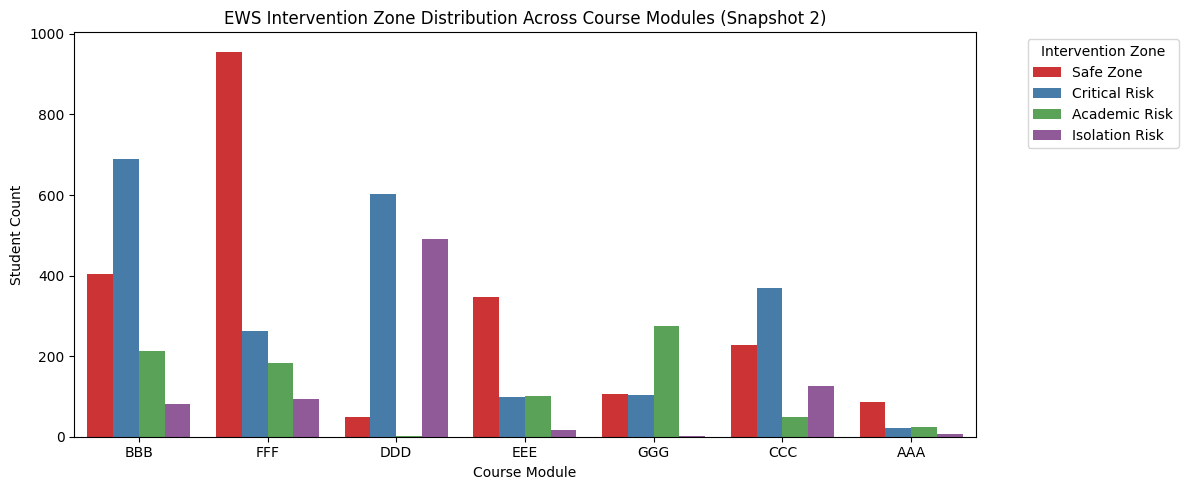

Exported: 'final_ews_snapshot2_complete_predictions.csv'
All figures and output tables saved in /kaggle/working/ directory.


In [19]:
# Apply the optimal risk threshold (0.35)
df_test["custom_risk_flag"] = (df_test["academic_risk_score"] >= 0.35).astype(int)

# Generate critical intervention alert list
critical_alerts = df_test[
    (df_test["custom_risk_flag"] == 1) & 
    (df_test["intervention_zone"].isin(["Critical Risk", "Academic Risk", "Isolation Risk"]))
].sort_values(by="academic_risk_score", ascending=False)

print("=" * 65)
print("ACTIONABLE EARLY WARNING SYSTEM (EWS) BATCH ALERT SUMMARY")
print("=" * 65)
print(f"Total Evaluated Test Instances     : {len(df_test)}")
print(f"Flagged At-Risk Students (p >= 0.35): {len(critical_alerts)}")
print(f"Proportion Requiring Intervention   : {(len(critical_alerts)/len(df_test))*100:.2f}%")
print("-" * 65)

# Export Top 50 Critical Alerts for Academic Interventions
alert_cols = [
    "id_student", "code_module", "code_presentation", "academic_risk_score", 
    "predicted_status", "intervention_zone", "days_since_last_click", "mean_score"
]
critical_alerts[alert_cols].head(50).to_csv("top_50_academic_risk_alerts.csv", index=False)
print("Exported: 'top_50_academic_risk_alerts.csv'")

# Plot Course Module Risk Breakdown
plt.figure(figsize=(12, 5))
sns.countplot(
    data=df_test, 
    x="code_module", 
    hue="intervention_zone", 
    palette="Set1"
)
plt.title("EWS Intervention Zone Distribution Across Course Modules (Snapshot 2)")
plt.xlabel("Course Module")
plt.ylabel("Student Count")
plt.legend(title="Intervention Zone", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("fig_course_module_risk_distribution.png", dpi=300)
plt.show()

# Export final prediction master file
df_test.to_csv("final_ews_snapshot2_complete_predictions.csv", index=False)
print("Exported: 'final_ews_snapshot2_complete_predictions.csv'")
print("All figures and output tables saved in /kaggle/working/ directory.")